# MNIST Autoencoder
Mini Project 2026

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

In [15]:
BATCH_SIZE = 128

transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print('Training set:', len(train_data))
print('Test set    :', len(test_data))

Training set: 60000
Test set    : 10000


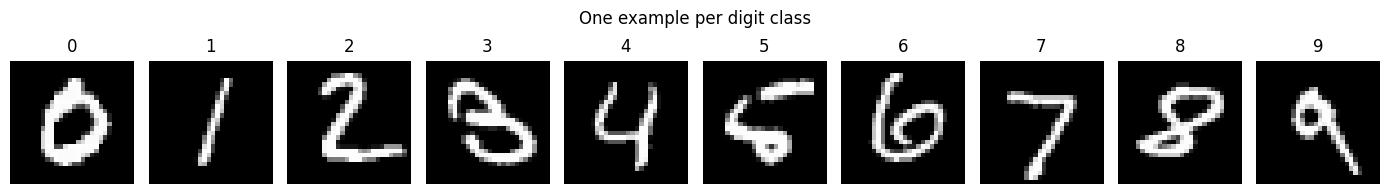

In [16]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for d in range(10):
    for idx in range(len(test_data)):
        img, lbl = test_data[idx]
        if lbl == d:
            axes[d].imshow(img.squeeze(), cmap='gray')
            axes[d].set_title(str(d))
            axes[d].axis('off')
            break
plt.suptitle('One example per digit class')
plt.tight_layout()
plt.savefig('fig1_digit_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
input_dim  = 28 * 28
hidden1    = 256
hidden2    = 64
latent_dim = 16

class MNISTAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),
            nn.Linear(hidden2, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2), nn.ReLU(),
            nn.Linear(hidden2, hidden1),    nn.ReLU(),
            nn.Linear(hidden1, input_dim),  nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(-1, input_dim)
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x.view(-1, input_dim))

model = MNISTAutoencoder()
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

MNISTAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 437664


In [18]:
lr = 0.001
num_epochs = 25

model = MNISTAutoencoder()
loss_fn   = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr)

epoch_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        optimiser.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, images.view(-1, input_dim))
        loss.backward()
        optimiser.step()
        running_loss += loss.item()
    avg = running_loss / len(train_loader)
    epoch_losses.append(avg)
    print('Epoch %d/%d  Loss: %.6f' % (epoch + 1, num_epochs, avg))

Epoch 1/25  Loss: 0.056562
Epoch 2/25  Loss: 0.031971
Epoch 3/25  Loss: 0.028018
Epoch 4/25  Loss: 0.025506
Epoch 5/25  Loss: 0.023818
Epoch 6/25  Loss: 0.022451
Epoch 7/25  Loss: 0.021617
Epoch 8/25  Loss: 0.020988
Epoch 9/25  Loss: 0.020490
Epoch 10/25  Loss: 0.020065
Epoch 11/25  Loss: 0.019701
Epoch 12/25  Loss: 0.019401
Epoch 13/25  Loss: 0.019115
Epoch 14/25  Loss: 0.018882
Epoch 15/25  Loss: 0.018664
Epoch 16/25  Loss: 0.018482
Epoch 17/25  Loss: 0.018322
Epoch 18/25  Loss: 0.018164
Epoch 19/25  Loss: 0.018018
Epoch 20/25  Loss: 0.017897
Epoch 21/25  Loss: 0.017768
Epoch 22/25  Loss: 0.017653
Epoch 23/25  Loss: 0.017553
Epoch 24/25  Loss: 0.017448
Epoch 25/25  Loss: 0.017365


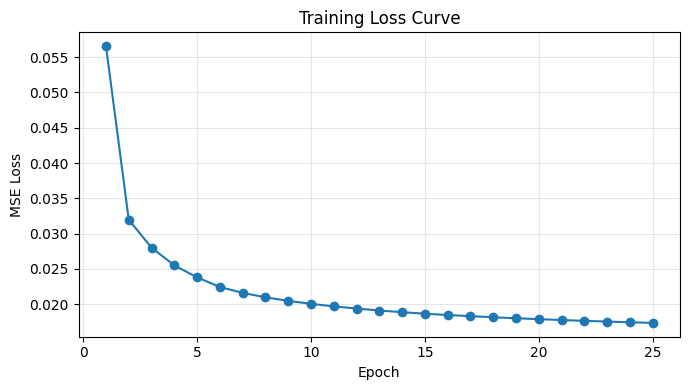

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
model.eval()
test_loss_total = 0.0
with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        test_loss_total += loss_fn(outputs, images.view(-1, input_dim)).item()

print('Average test MSE:', round(test_loss_total / len(test_loader), 6))

Average test MSE: 0.017603


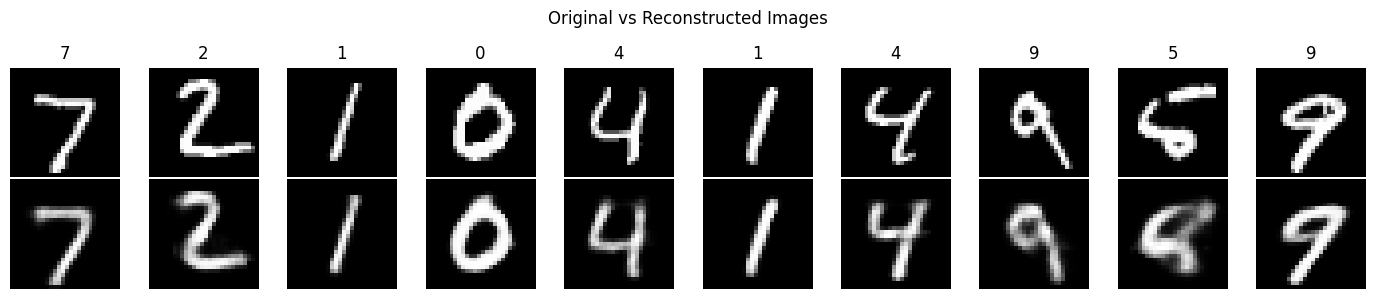

In [21]:
model.eval()
sample_imgs, sample_lbls = next(iter(test_loader))

with torch.no_grad():
    recon = model(sample_imgs)

n = 10
fig, axes = plt.subplots(2, n, figsize=(14, 3))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i].view(28, 28), cmap='gray')
    axes[0, i].set_title(str(sample_lbls[i].item()))
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].view(28, 28).numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Input')
axes[1, 0].set_ylabel('Output')
plt.suptitle('Original vs Reconstructed Images')
plt.tight_layout()
plt.savefig('fig3_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
model.eval()
latent_vecs = []
label_list  = []

with torch.no_grad():
    for images, labels in test_loader:
        latent_vecs.append(model.encode(images).numpy())
        label_list.append(labels.numpy())

latent_vecs = np.vstack(latent_vecs)
label_list  = np.concatenate(label_list)

print('Latent shape:', latent_vecs.shape)

Latent shape: (10000, 16)


In [23]:
latent_mean   = np.mean(latent_vecs, axis=0)
latent_centre = latent_vecs - latent_mean
cov_matrix    = latent_centre.T @ latent_centre / (len(latent_centre) - 1)

eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
order    = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

projected = latent_centre @ eig_vecs[:, :2]
var_ratio = eig_vals[:2] / eig_vals.sum() * 100

print('PC1 explains %.2f%% of variance' % var_ratio[0])
print('PC2 explains %.2f%% of variance' % var_ratio[1])

PC1 explains 28.64% of variance
PC2 explains 23.82% of variance


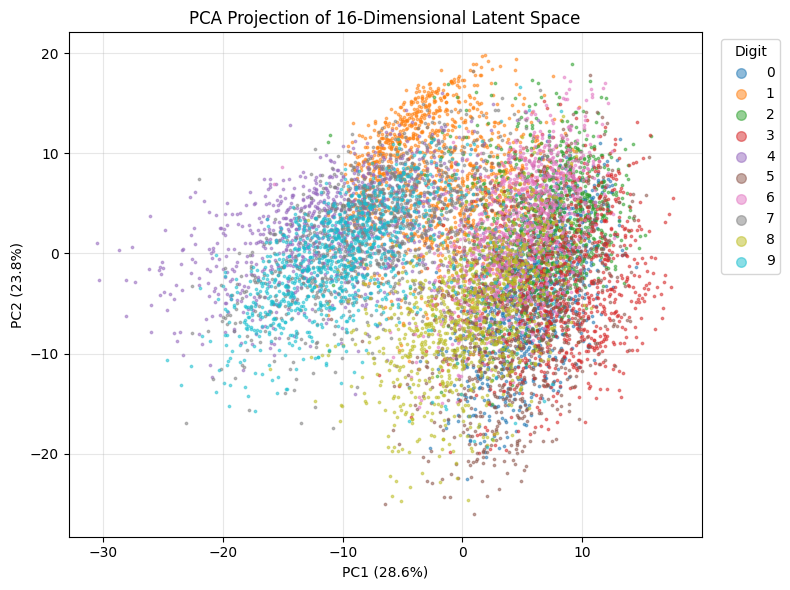

Mean PCA coordinates per digit:
  0 -> (5.71, -4.12)
  1 -> (-2.08, 8.02)
  2 -> (6.88, 2.71)
  3 -> (8.05, -2.88)
  4 -> (-10.41, 2.51)
  5 -> (4.62, -5.87)
  6 -> (4.77, 2.34)
  7 -> (-7.40, 2.19)
  8 -> (0.54, -6.28)
  9 -> (-9.77, -0.55)


In [24]:
cmap_colours = plt.cm.tab10(np.linspace(0, 1, 10))

plt.figure(figsize=(8, 6))
for d in range(10):
    mask = label_list == d
    plt.scatter(projected[mask, 0], projected[mask, 1],
                label=str(d), s=3, alpha=0.5, color=cmap_colours[d])
plt.xlabel('PC1 (%.1f%%)' % var_ratio[0])
plt.ylabel('PC2 (%.1f%%)' % var_ratio[1])
plt.title('PCA Projection of %d-Dimensional Latent Space' % latent_dim)
plt.legend(title='Digit', markerscale=4, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_pca_latent.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean PCA coordinates per digit:')
for d in range(10):
    m = label_list == d
    print('  %d -> (%.2f, %.2f)' % (d, projected[m, 0].mean(), projected[m, 1].mean()))

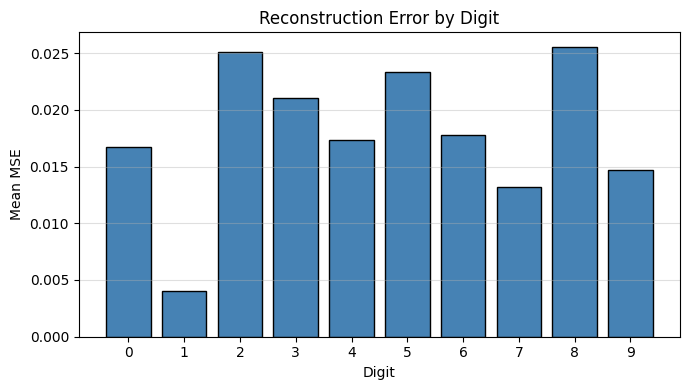

  Digit 0: 0.016725
  Digit 1: 0.004072
  Digit 2: 0.025083
  Digit 3: 0.021040
  Digit 4: 0.017358
  Digit 5: 0.023370
  Digit 6: 0.017755
  Digit 7: 0.013153
  Digit 8: 0.025549
  Digit 9: 0.014705
Easiest: 1  Hardest: 8


In [25]:
model.eval()
error_sum   = np.zeros(10)
error_count = np.zeros(10)

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        for i in range(len(labels)):
            err = loss_fn(outputs[i], images[i].view(input_dim)).item()
            error_sum[labels[i].item()]   += err
            error_count[labels[i].item()] += 1

mean_error = error_sum / error_count

plt.figure(figsize=(7, 4))
plt.bar(range(10), mean_error, color='steelblue', edgecolor='black')
plt.xlabel('Digit')
plt.ylabel('Mean MSE')
plt.title('Reconstruction Error by Digit')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('fig5_digit_error.png', dpi=150, bbox_inches='tight')
plt.show()

for d in range(10):
    print('  Digit %d: %.6f' % (d, mean_error[d]))
print('Easiest:', np.argmin(mean_error), ' Hardest:', np.argmax(mean_error))

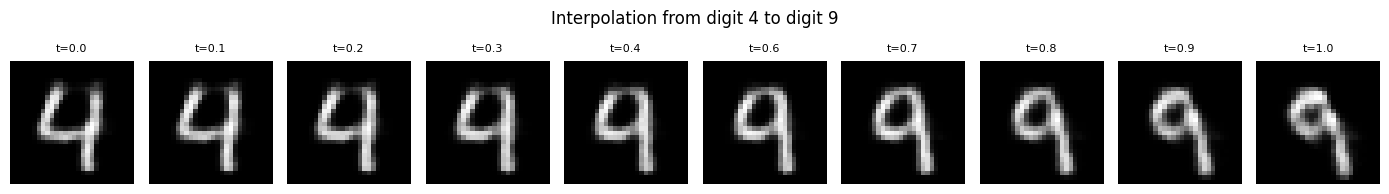

In [26]:
model.eval()
idx_start, idx_end = None, None
for i in range(len(test_data)):
    if idx_start is None and test_data[i][1] == 4:
        idx_start = i
    if idx_end is None and test_data[i][1] == 9:
        idx_end = i
    if idx_start is not None and idx_end is not None:
        break

with torch.no_grad():
    z_start = model.encode(test_data[idx_start][0].unsqueeze(0))
    z_end   = model.encode(test_data[idx_end][0].unsqueeze(0))

steps = 10
fig, axes = plt.subplots(1, steps, figsize=(14, 2))
for i, t in enumerate(np.linspace(0, 1, steps)):
    z_mix = (1 - t) * z_start + t * z_end
    with torch.no_grad():
        img = model.decoder(z_mix).view(28, 28).numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title('t=%.1f' % t, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Interpolation from digit %d to digit %d' % (test_data[idx_start][1], test_data[idx_end][1]))
plt.tight_layout()
plt.savefig('fig6_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()